In [1]:
#!/g/data/xp65/public/apps/med_conda_scripts/analysis3-25.07.d/bin/python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import xesmf as xe

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)
# qsub -I -q normal -P er8 -l walltime=2:00:00,ncpus=24,mem=120GB,jobfs=100MB,storage=gdata/xp65+gdata/er8+gdata/ob53+gdata/rt52+gdata/rv74+gdata/su28

# Set up Dask

In [2]:
# client = setup_dask_client(workload_type="cpu")
client = Client(
    n_workers=48,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 48
Total threads: 48,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46009,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36429,Total threads: 1
Dashboard: /proxy/38523/status,Memory: 1.98 GiB
Nanny: tcp://127.0.0.1:44735,


# Prepare Data

In [3]:
year = '2018'
file_path = Path(f"/scratch/er8/cd3022/Irradiance-comparisons/himawari_barrar2_diffct_{year}.zarr")
ds = xr.open_zarr(file_path, consolidated=False)

# Plot Time Step of All Cloud Types
From Sam Green's tutorial notebook code

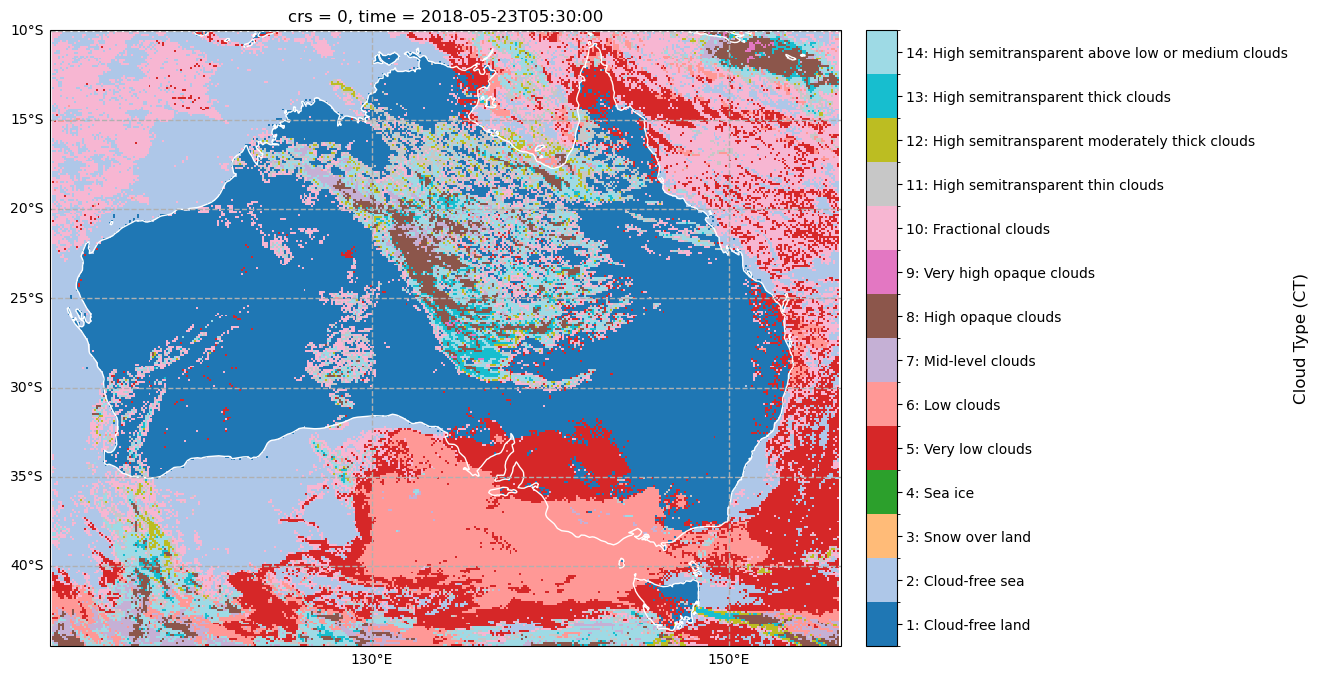

In [4]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
import cmocean as cmo
import matplotlib as mpl
import matplotlib.ticker as mticker

import re

comment = '1:  Cloud-free land; 2:  Cloud-free sea; 3:  Snow over land;  4:  Sea ice; 5:  Very low clouds; 6:  Low clouds; 7:  Mid-level clouds;  8:  High opaque clouds; 9:  Very high opaque clouds;  10:  Fractional clouds; 11:  High semitransparent thin clouds;  12:  High semitransparent moderately thick clouds;  13:  High semitransparent thick clouds;  14:  High semitransparent above low or medium clouds;  15:  High semitransparent above snow/ice'

# Use regex to extract values and labels
matches = re.findall(r'(\d+):\s+([^;]+)', comment)
category_dict = {int(num): desc.strip() for num, desc in matches}

fig = plt.figure(figsize=(16, 8))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=130))
ax.coastlines(resolution="50m", color='white')

# Define the values and corresponding colors from tab20
values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # Adjust based on your dataset
# Set the min and max colors from tab20
min_color = mpl.colormaps['tab20'](0 / 20)
max_color = mpl.colormaps['tab20'](19 / 20)  # Last color of tab20

# Generate intermediate colors by linearly spacing them within tab20
num_classes = len(values)
colors = [mpl.colormaps['tab20'](i / (num_classes - 1)) for i in range(num_classes)]

# Ensure min/max colors are set explicitly
colors[0] = min_color
colors[-1] = max_color

# Create discrete colormap
cmap = mcolors.ListedColormap(colors)
# Define boundaries for normalization (each value gets its own bin)
boundaries = np.arange(min(values) - 0.5, max(values) + 1.5, 1)  # Adjusted for correct binning
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

img = ds.sel(time=f'{year}-05-23T05:30:00.000000000').ct.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)

# Add a discrete colorbar
cbar = fig.colorbar(img, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Cloud Type (CT)", fontsize=12)
cbar.set_ticks(values)  # Ensure ticks match category values
cbar.set_ticklabels([f"{k}: {v}" for k, v in sorted(category_dict.items())[:14]])  # Custom labels

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=1.0)
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels

# Increase the number of ticks on the x-axis
gl.xlocator = mticker.FixedLocator(np.arange(70, 190, 20))  # Adjust step size as needed

# CT Errors

## Example for one ct at a single time

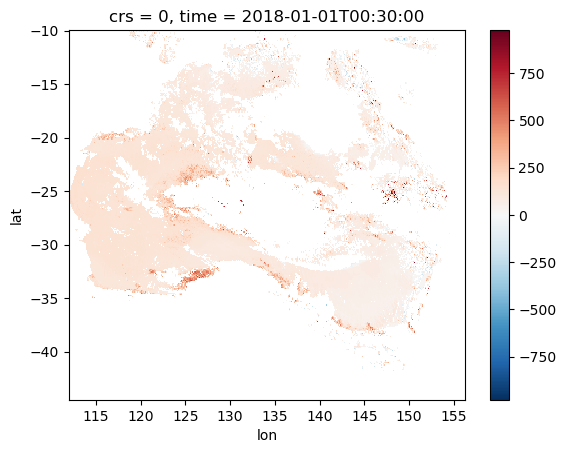

In [5]:
time=f'{year}-01-01T00:30'

ds_slice = ds.sel(time=time, method='nearest')

xr.where(
    ds_slice.ct.isin([1,2,3,4]), ds_slice.ghi_diff, np.nan
).plot()

## Loop over CTs and calculate each of their errors

In [6]:
cloud_aggs = {
    'clear_sky':[1,2,3,4],
    'low_clouds':[5,6],
    'med_clouds':[7],
    'high_clouds':[8,9,10,11,12,13,14]
}

In [7]:
# xr.where(ds.ghi_diff.isnull(), 1, 0).sum().compute()

In [8]:
# (xr.where(~ds.ct.isin([1,2,3,4,5,6,7,8,9,10,11,12,13,14]), 1, 0).sum().compute() / ds.ct.count()).compute().item()

In [ ]:
total = xr.where(ds.ghi_diff.isnull(), 0, 1).sum().compute().item()

rmse = {}
ct_counts = {}
# for ct in cloud_aggs:
for ct in range(1,15):
    # ct_codes = cloud_aggs[ct]
    # ct_diffs = xr.where(ds.ct.isin(ct_codes), ds.ghi_diff, np.nan)
    ct_diffs = xr.where(ds.ct == ct, ds.ghi_diff, np.nan)
    ct_errors = np.sqrt((ct_diffs**2).mean(dim=['lat', 'lon'], skipna=True)).compute().data
    ct_errors = ct_errors[~np.isnan(ct_errors)]
    rmse[ct] = ct_errors

    # ct_counts[ct] = xr.where(
    #     ds.ct.isin(ct_codes) & ~(ds.ghi_diff.isnull()), 1, 0
    # ).sum().compute().data / total
    ct_counts[ct] = xr.where(
        (ds.ct == ct) & (ds.ghi_diff.notnull()), 1, 0
    ).sum().compute().item() / total

In [ ]:
sum(ct_counts.values())

In [ ]:
plt.bar(ct_counts.keys(), ct_counts.values())
plt.title(year)
plt.xlabel('ct')
plt.ylabel('frequency')
plt.savefig(f'/home/548/cd3022/figures/Irradiance_comparisons/{year}_ct_histogram.png')

In [ ]:
plt.boxplot(
    rmse.values(),
    tick_labels=rmse.keys(),
)
plt.xlabel('cloud type')
plt.ylabel('rmse')
plt.title(year)
plt.savefig(f'/home/548/cd3022/figures/Irradiance_comparisons/{year}_ct_error_boxplot.png')